"Dataset cleaned — handled NaN values in Fat and Sat.Fat with fillna(0), dropped rows with missing Calories/Protein/Fiber/Carbs. 335 rows → 291 rows."

In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\DEVIL\PythonPrograms\nutrients_csvfile.csv")
print(df.shape)
print(df.head())

(335, 10)
                    Food Measure  Grams Calories Protein Fat Sat.Fat Fiber  \
0             Cows' milk   1 qt.    976      660      32  40      36     0   
1              Milk skim   1 qt.    984      360      36   t       t     0   
2             Buttermilk   1 cup    246      127       9   5       4     0   
3  Evaporated, undiluted   1 cup    252      345      16  20      18     0   
4         Fortified milk  6 cups  1,419    1,373      89  42      23   1.4   

  Carbs        Category  
0    48  Dairy products  
1    52  Dairy products  
2    13  Dairy products  
3    24  Dairy products  
4   119  Dairy products  


In [2]:
print(df.shape)

(335, 10)


In [3]:
print(df["Category"].unique())

['Dairy products' 'Fats, Oils, Shortenings' 'Meat, Poultry'
 'Fish, Seafood' 'Vegetables A-E' 'Vegetables F-P' 'Vegetables R-Z'
 'Fruits A-F' 'Fruits G-P' 'Fruits R-Z' 'Breads, cereals, fastfood,grains'
 'Soups' 'Desserts, sweets' 'Jams, Jellies' 'Seeds and Nuts'
 'Drinks,Alcohol, Beverages']


In [4]:
print(df.describe())

          Food Measure Grams Calories Protein  Fat Sat.Fat Fiber Carbs  \
count      335     335   335      334     335  335     333   335   335   
unique     329      61   103      152      40   45      38    57    80   
top     Butter   1 cup   100      100       1    t       0     0     0   
freq         3     120    38       14      53  115     174   116    45   

                                Category  
count                                335  
unique                                16  
top     Breads, cereals, fastfood,grains  
freq                                  45  


In [5]:
dairy = df[df["Category"] == "Dairy products"]
print(dairy)

                       Food     Measure  Grams Calories Protein Fat Sat.Fat  \
0                Cows' milk       1 qt.    976      660      32  40      36   
1                 Milk skim       1 qt.    984      360      36   t       t   
2                Buttermilk       1 cup    246      127       9   5       4   
3     Evaporated, undiluted       1 cup    252      345      16  20      18   
4            Fortified milk      6 cups  1,419    1,373      89  42      23   
5             Powdered milk       1 cup    103      515      27  28      24   
6             skim, instant  1 1/3 cups     85      290      30   t       t   
7         skim, non-instant     2/3 cup     85      290      30   t       t   
8               Goats' milk       1 cup    244      165       8  10       8   
9       (1/2 cup ice cream)      2 cups    540      690      24  24      22   
10                    Cocoa       1 cup    252      235       8  11      10   
11               skim. milk       1 cup    250      

In [6]:
meat = df[df["Category"] == "Meat, Poultry"]
print(meat.shape)

(30, 10)


In [7]:
fish = df[df["Category"] == "Fish, Seafood"]
print(fish.shape)

(19, 10)


In [8]:
print(df["Category"].value_counts())

Category
Breads, cereals, fastfood,grains    45
Meat, Poultry                       30
Desserts, sweets                    29
Dairy products                      28
Vegetables A-E                      28
Vegetables R-Z                      28
Fruits G-P                          28
Fruits A-F                          22
Fish, Seafood                       19
Fats, Oils, Shortenings             14
Vegetables F-P                      14
Seeds and Nuts                      12
Drinks,Alcohol, Beverages           12
Soups                               10
Fruits R-Z                           8
Jams, Jellies                        8
Name: count, dtype: int64


In [9]:
fish = df[df["Category"] == "Fish, Seafood"][["Food", "Calories", "Protein"]]
print(fish)

                 Food Calories Protein
72              Clams       87      12
73                Cod      170      28
74          Crab meat       90      14
75  Fish sticks fried      200      19
76           Flounder      200      30
77            Haddock      135      16
78            Halibut      182      26
79            Herring      211      22
80            Lobster       92      18
81           Mackerel      155      18
82            Oysters      231     232
83        Oyster stew      125      19
84             Salmon      120      17
85           Sardines      180      22
86           Scallops      104      18
87               Shad      170      20
88             Shrimp      110      23
89          Swordfish      180      27
90               Tuna      170      25


In [10]:
df.loc[82, ["Calories", "Protein", "Fat", "Sat.Fat", "Fiber", "Carbs"]] = [150, 18, 5, 1, 0, 9]
print(df.loc[82])

Food              Oysters
Measure          6-8 med.
Grams                 230
Calories              150
Protein                18
Fat                     5
Sat.Fat                 1
Fiber                   0
Carbs                   9
Category    Fish, Seafood
Name: 82, dtype: object


In [11]:
suspicious = df[df["Protein"] > df["Calories"]]
print(suspicious)

                      Food     Measure  Grams Calories Protein Fat Sat.Fat  \
2               Buttermilk       1 cup    246      127       9   5       4   
4           Fortified milk      6 cups  1,419    1,373      89  42      23   
6            skim, instant  1 1/3 cups     85      290      30   t       t   
7        skim, non-instant     2/3 cup     85      290      30   t       t   
8              Goats' milk       1 cup    244      165       8  10       8   
..                     ...         ...    ...      ...     ...  ..     ...   
322                Walnuts     1/2 cup     50      325       7  32       7   
323                   Beer      2 cups    480      228       t   0       0   
325                  Wines     1/2 cup    120      164       t   0       0   
326  Table (12.2% alcohol)     1/2 cup    120      100       t   0       0   
333                 Coffee       1 cup    230        3       t   0       0   

    Fiber Carbs                   Category  
2       0    13   

In [12]:
df["Calories"] = pd.to_numeric(df["Calories"], errors = "coerce")
df["Protein"] = pd.to_numeric(df["Calories"], errors = "coerce")
df["Fat"] = pd.to_numeric(df["Fat"], errors = "coerce")
df["Sat.Fat"] = pd.to_numeric(df["Sat.Fat"], errors = "coerce")
df["Fiber"] = pd.to_numeric(df["Fiber"], errors = "coerce")
df["Carbs"] = pd.to_numeric(df["Carbs"], errors="coerce")

suspicious = df[df["Protein"] > df["Calories"]]
print(suspicious[["Food", "Calories", "Protein"]])
print("Total suspicious rows:", len(suspicious))

Empty DataFrame
Columns: [Food, Calories, Protein]
Index: []
Total suspicious rows: 0


In [13]:
df.isnull().sum()

Food          0
Measure       0
Grams         0
Calories      5
Protein       5
Fat         116
Sat.Fat      17
Fiber        27
Carbs        13
Category      0
dtype: int64

In [14]:
df[df["Fat"].isnull()].head(10)

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
1,Milk skim,1 qt.,984,360.0,360.0,NaN,NaN,0.0,52.0,Dairy products
6,"skim, instant",1 1/3 cups,85,290.0,290.0,NaN,NaN,0.0,42.0,Dairy products
7,"skim, non-instant",2/3 cup,85,290.0,290.0,NaN,NaN,1.0,42.0,Dairy products
19,uncreamed,1 cup,225,195.0,195.0,NaN,NaN,0.0,6.0,Dairy products
91,Artichoke,1 large,100,NaN,NaN,NaN,NaN,2.0,10.0,Vegetables A-E
92,Asparagus,6 spears,96,18.0,18.0,NaN,NaN,0.5,3.0,Vegetables A-E
93,Beans,1 cup,125,25.0,25.0,NaN,NaN,0.8,6.0,Vegetables A-E
94,Lima,1 cup,160,140.0,140.0,NaN,NaN,3.0,24.0,Vegetables A-E
95,"Lima, dry, cooked",1 cup,192,260.0,260.0,NaN,NaN,2.0,48.0,Vegetables A-E
98,Bean sprouts,1 cup,50,17.0,17.0,NaN,0.0,0.3,3.0,Vegetables A-E


In [15]:
df["Fat"] = df["Fat"].fillna(0)

In [16]:
df["Sat.Fat"] = df["Sat.Fat"].fillna(0)
df.dropna(inplace = True)
df.isnull().sum()

Food        0
Measure     0
Grams       0
Calories    0
Protein     0
Fat         0
Sat.Fat     0
Fiber       0
Carbs       0
Category    0
dtype: int64

In [17]:
len(df)

291

In [18]:
df.groupby("Category")["Calories"].mean().sort_values(ascending=False)

Category
Seeds and Nuts                      340.750000
Dairy products                      296.636364
Meat, Poultry                       267.185185
Fats, Oils, Shortenings             265.888889
Breads, cereals, fastfood,grains    240.171429
Desserts, sweets                    238.120000
Jams, Jellies                       184.285714
Fruits R-Z                          153.500000
Fish, Seafood                       152.000000
Fruits A-F                          151.272727
Fruits G-P                          126.208333
Soups                               119.100000
Vegetables R-Z                      106.625000
Drinks,Alcohol, Beverages            94.727273
Vegetables A-E                       68.384615
Vegetables F-P                       58.083333
Name: Calories, dtype: float64

In [19]:
df.groupby("Category")["Protein"].mean().sort_values(ascending=False)

Category
Seeds and Nuts                      340.750000
Dairy products                      296.636364
Meat, Poultry                       267.185185
Fats, Oils, Shortenings             265.888889
Breads, cereals, fastfood,grains    240.171429
Desserts, sweets                    238.120000
Jams, Jellies                       184.285714
Fruits R-Z                          153.500000
Fish, Seafood                       152.000000
Fruits A-F                          151.272727
Fruits G-P                          126.208333
Soups                               119.100000
Vegetables R-Z                      106.625000
Drinks,Alcohol, Beverages            94.727273
Vegetables A-E                       68.384615
Vegetables F-P                       58.083333
Name: Protein, dtype: float64

In [20]:
df[["Food", "Calories", "Protein"]].head(10)

,Food,Calories,Protein
0,Cows' milk,660.0,660.0
1,Milk skim,360.0,360.0
2,Buttermilk,127.0,127.0
3,"Evaporated, undiluted",345.0,345.0
5,Powdered milk,515.0,515.0
6,"skim, instant",290.0,290.0
7,"skim, non-instant",290.0,290.0
8,Goats' milk,165.0,165.0
9,(1/2 cup ice cream),690.0,690.0
10,Cocoa,235.0,235.0


In [21]:
df = pd.read_csv(r"C:\Users\DEVIL\PythonPrograms\nutrients_csvfile.csv")
df["Calories"] = pd.to_numeric(df["Calories"], errors = "coerce")
df["Protein"] = pd.to_numeric(df["Protein"], errors = "coerce")
df["Fat"] = pd.to_numeric(df["Fat"], errors = "coerce")
df["Sat.Fat"] = pd.to_numeric(df["Sat.Fat"], errors = "coerce")
df["Fiber"] = pd.to_numeric(df["Fiber"], errors = "coerce")
df["Carbs"] = pd.to_numeric(df["Carbs"], errors = "coerce")
df["Fat"] = df["Fat"].fillna(0)
df["Sat.Fat"] = df["Sat.Fat"].fillna(0)
df.dropna(inplace=True)
df[["Food", "Calories", "Protein"]].head(10)

,Food,Calories,Protein
0,Cows' milk,660.0,32.0
1,Milk skim,360.0,36.0
2,Buttermilk,127.0,9.0
3,"Evaporated, undiluted",345.0,16.0
5,Powdered milk,515.0,27.0
6,"skim, instant",290.0,30.0
7,"skim, non-instant",290.0,30.0
8,Goats' milk,165.0,8.0
9,(1/2 cup ice cream),690.0,24.0
10,Cocoa,235.0,8.0


In [22]:
df.groupby("Category")["Protein"].mean().sort_values(ascending=False)

Category
Fish, Seafood                       33.529412
Fats, Oils, Shortenings             32.571429
Meat, Poultry                       18.666667
Dairy products                      17.181818
Seeds and Nuts                      10.000000
Breads, cereals, fastfood,grains     7.942857
Soups                                5.900000
Vegetables R-Z                       4.409091
Vegetables A-E                       4.125000
Vegetables F-P                       3.800000
Desserts, sweets                     3.350000
Fruits A-F                           1.705882
Fruits R-Z                           1.400000
Fruits G-P                           1.227273
Drinks,Alcohol, Beverages            0.000000
Jams, Jellies                        0.000000
Name: Protein, dtype: float64

In [23]:
df.groupby("Category")["Fat"].mean().sort_values(ascending=False)

Category
Fats, Oils, Shortenings             68.857143
Seeds and Nuts                      30.666667
Fish, Seafood                       19.823529
Meat, Poultry                       19.592593
Dairy products                      14.090909
Desserts, sweets                     6.100000
Soups                                4.100000
Breads, cereals, fastfood,grains     3.828571
Vegetables R-Z                       3.136364
Fruits A-F                           1.176471
Fruits G-P                           1.136364
Vegetables A-E                       0.375000
Fruits R-Z                           0.200000
Vegetables F-P                       0.200000
Drinks,Alcohol, Beverages            0.000000
Jams, Jellies                        0.000000
Name: Fat, dtype: float64

In [24]:
df.columns

Index(['Food', 'Measure', 'Grams', 'Calories', 'Protein', 'Fat', 'Sat.Fat',
       'Fiber', 'Carbs', 'Category'],
      dtype='object')

In [25]:
df["protein_per_calorie"] = df["Protein"] / df["Calories"]
print(df[["Food", "Calories", "Protein", "protein_per_calorie"]])

                      Food  Calories  Protein  protein_per_calorie
0               Cows' milk     660.0     32.0             0.048485
1                Milk skim     360.0     36.0             0.100000
2               Buttermilk     127.0      9.0             0.070866
3    Evaporated, undiluted     345.0     16.0             0.046377
5            Powdered milk     515.0     27.0             0.052427
..                     ...       ...      ...                  ...
329            Cola drinks     137.0      0.0             0.000000
330    Fruit-flavored soda     161.0      0.0             0.000000
331             Ginger ale     105.0      0.0             0.000000
332              Root beer     140.0      0.0             0.000000
334                    Tea       4.0      0.0             0.000000

[263 rows x 4 columns]


In [26]:
print(df.sort_values("protein_per_calorie", ascending=False)[["Food", "Calories", "Protein", "protein_per_calorie"]].head(10))

                       Food  Calories  Protein  protein_per_calorie
31                   Butter     113.0    114.0             1.008850
30                   Butter     113.0    114.0             1.008850
82                  Oysters     231.0    232.0             1.004329
88                   Shrimp     110.0     23.0             0.209091
266                Bouillon      24.0      5.0             0.208333
110               Stalk raw       5.0      1.0             0.200000
19                uncreamed     195.0     38.0             0.194872
86                 Scallops     104.0     18.0             0.173077
52   Corned beef hash Dried     115.0     19.0             0.165217
73                      Cod     170.0     28.0             0.164706


In [27]:
df[df["Food"].str.contains("Butter | Oysters", case=False)]

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category,protein_per_calorie


In [28]:
df.loc[[30, 31, 82]]

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category,protein_per_calorie
30,Butter,1/2 cup,112,113.0,114.0,115.0,116.0,117.0,118.0,"Fats, Oils, Shortenings",1.008850
31,Butter,1/4 lb.,112,113.0,114.0,115.0,116.0,117.0,118.0,"Fats, Oils, Shortenings",1.008850
82,Oysters,6-8 med.,230,231.0,232.0,233.0,234.0,235.0,236.0,"Fish, Seafood",1.004329


In [29]:
df = df.drop([30, 31, 82])
print(len(df))

260


In [30]:
print(df.sort_values("protein_per_calorie", ascending=False)[["Food", "Calories", "Protein", "protein_per_calorie"]].head(10))

                       Food  Calories  Protein  protein_per_calorie
88                   Shrimp     110.0     23.0             0.209091
266                Bouillon      24.0      5.0             0.208333
110               Stalk raw       5.0      1.0             0.200000
19                uncreamed     195.0     38.0             0.194872
86                 Scallops     104.0     18.0             0.173077
52   Corned beef hash Dried     115.0     19.0             0.165217
73                      Cod     170.0     28.0             0.164706
58    Chicken livers, fried     140.0     22.0             0.157143
74                Crab meat      90.0     14.0             0.155556
83              Oyster stew     125.0     19.0             0.152000


    "Top 10 foods by protein efficiency — seafood dominates. Confirmed by both individual ranking and category-level GroupBy analysis."

In [31]:
df.loc[[88]]

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category,protein_per_calorie
88,Shrimp,3 oz.,85,110.0,23.0,1.0,0.0,0.0,0.0,"Fish, Seafood",0.209091


In [32]:
df[df["Food"] == "Shrimp"]

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category,protein_per_calorie
88,Shrimp,3 oz.,85,110.0,23.0,1.0,0.0,0.0,0.0,"Fish, Seafood",0.209091


In [33]:
def get_food_info(food_name):
    result = df[df["Food"] == food_name]
    return result

In [34]:
get_food_info("Shrimp")

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category,protein_per_calorie
88,Shrimp,3 oz.,85,110.0,23.0,1.0,0.0,0.0,0.0,"Fish, Seafood",0.209091


In [35]:
get_food_info("Cod")

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category,protein_per_calorie
73,Cod,3 1/2 oz.,100,170.0,28.0,5.0,0.0,0.0,0.0,"Fish, Seafood",0.164706


In [36]:
get_food_info("Buttermilk")

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category,protein_per_calorie
2,Buttermilk,1 cup,246,127.0,9.0,5.0,4.0,0.0,13.0,Dairy products,0.070866


In [37]:
df[df["Calories"] < 200].sort_values("Protein", ascending=False).head(10)

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category,protein_per_calorie
19,uncreamed,1 cup,225,195.0,38.0,0.0,0.0,0.0,6.0,Dairy products,0.194872
73,Cod,3 1/2 oz.,100,170.0,28.0,5.0,0.0,0.0,0.0,"Fish, Seafood",0.164706
89,Swordfish,1 steak,100,180.0,27.0,6.0,0.0,0.0,0.0,"Fish, Seafood",0.150000
78,Halibut,3 1/2 oz.,100,182.0,26.0,8.0,0.0,0.0,0.0,"Fish, Seafood",0.142857
90,Tuna,3 oz.,85,170.0,25.0,7.0,3.0,0.0,0.0,"Fish, Seafood",0.147059
46,Ground lean,3 oz.,85,185.0,24.0,10.0,9.0,0.0,0.0,"Meat, Poultry",0.129730
88,Shrimp,3 oz.,85,110.0,23.0,1.0,0.0,0.0,0.0,"Fish, Seafood",0.209091
70,Veal,3 oz.,85,185.0,23.0,9.0,8.0,0.0,0.0,"Meat, Poultry",0.124324
55,chicken,3 oz.,85,185.0,23.0,9.0,7.0,0.0,0.0,"Meat, Poultry",0.124324
85,Sardines,3 oz.,85,180.0,22.0,9.0,4.0,0.0,0.0,"Fish, Seafood",0.122222


In [38]:
def get_high_protein_foods(calorie_limit):
    result = df[df["Calories"] < calorie_limit].sort_values("Protein", ascending=False).head(10)
    return result

In [39]:
get_high_protein_foods(200)

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category,protein_per_calorie
19,uncreamed,1 cup,225,195.0,38.0,0.0,0.0,0.0,6.0,Dairy products,0.194872
73,Cod,3 1/2 oz.,100,170.0,28.0,5.0,0.0,0.0,0.0,"Fish, Seafood",0.164706
89,Swordfish,1 steak,100,180.0,27.0,6.0,0.0,0.0,0.0,"Fish, Seafood",0.150000
78,Halibut,3 1/2 oz.,100,182.0,26.0,8.0,0.0,0.0,0.0,"Fish, Seafood",0.142857
90,Tuna,3 oz.,85,170.0,25.0,7.0,3.0,0.0,0.0,"Fish, Seafood",0.147059
46,Ground lean,3 oz.,85,185.0,24.0,10.0,9.0,0.0,0.0,"Meat, Poultry",0.129730
88,Shrimp,3 oz.,85,110.0,23.0,1.0,0.0,0.0,0.0,"Fish, Seafood",0.209091
70,Veal,3 oz.,85,185.0,23.0,9.0,8.0,0.0,0.0,"Meat, Poultry",0.124324
55,chicken,3 oz.,85,185.0,23.0,9.0,7.0,0.0,0.0,"Meat, Poultry",0.124324
85,Sardines,3 oz.,85,180.0,22.0,9.0,4.0,0.0,0.0,"Fish, Seafood",0.122222


In [40]:
get_high_protein_foods(150)

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category,protein_per_calorie
88,Shrimp,3 oz.,85,110.0,23.0,1.0,0.0,0.0,0.0,"Fish, Seafood",0.209091
58,"Chicken livers, fried",3 med.,100,140.0,22.0,14.0,12.0,0.0,2.3,"Meat, Poultry",0.157143
83,Oyster stew,1 cup,85,125.0,19.0,6.0,1.0,0.0,0.0,"Fish, Seafood",0.152000
52,Corned beef hash Dried,2 oz.,56,115.0,19.0,4.0,4.0,0.0,0.0,"Meat, Poultry",0.165217
86,Scallops,3 1/2 oz.,100,104.0,18.0,8.0,0.0,0.0,10.0,"Fish, Seafood",0.173077
11,skim. milk,1 cup,250,128.0,18.0,4.0,3.0,1.0,13.0,Dairy products,0.140625
84,Salmon,3 oz.,85,120.0,17.0,5.0,1.0,0.0,0.0,"Fish, Seafood",0.141667
77,Haddock,3 oz.,85,135.0,16.0,5.0,4.0,0.0,6.0,"Fish, Seafood",0.118519
74,Crab meat,3 oz.,85,90.0,14.0,2.0,0.0,0.0,1.0,"Fish, Seafood",0.155556
72,Clams,3 oz.,85,87.0,12.0,1.0,0.0,0.0,2.0,"Fish, Seafood",0.137931


In [41]:
df[["Food", "Grams", "Calories", "Protein", "Fat", "Sat.Fat", "Fiber", "Carbs", "Category", "protein_per_calorie"]]

,Food,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category,protein_per_calorie
0,Cows' milk,976,660.0,32.0,40.0,36.0,0.0,48.0,Dairy products,0.048485
1,Milk skim,984,360.0,36.0,0.0,0.0,0.0,52.0,Dairy products,0.100000
2,Buttermilk,246,127.0,9.0,5.0,4.0,0.0,13.0,Dairy products,0.070866
3,"Evaporated, undiluted",252,345.0,16.0,20.0,18.0,0.0,24.0,Dairy products,0.046377
5,Powdered milk,103,515.0,27.0,28.0,24.0,0.0,39.0,Dairy products,0.052427
...,...,...,...,...,...,...,...,...,...,...
329,Cola drinks,346,137.0,0.0,0.0,0.0,0.0,38.0,"Drinks,Alcohol, Beverages",0.000000
330,Fruit-flavored soda,346,161.0,0.0,0.0,0.0,0.0,42.0,"Drinks,Alcohol, Beverages",0.000000
331,Ginger ale,346,105.0,0.0,0.0,0.0,0.0,28.0,"Drinks,Alcohol, Beverages",0.000000
332,Root beer,346,140.0,0.0,0.0,0.0,0.0,35.0,"Drinks,Alcohol, Beverages",0.000000


In [42]:
def get_high_protein_foods(calorie_limit):
    result = df[df["Calories"] < calorie_limit].sort_values("Protein", ascending=False).head(10)
    result = result[["Food", "Grams", "Calories", "Protein", "Fat", "Sat.Fat", "Fiber", "Carbs", "Category", "protein_per_calorie"]]
    return result

In [43]:
get_high_protein_foods(150)

,Food,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category,protein_per_calorie
88,Shrimp,85,110.0,23.0,1.0,0.0,0.0,0.0,"Fish, Seafood",0.209091
58,"Chicken livers, fried",100,140.0,22.0,14.0,12.0,0.0,2.3,"Meat, Poultry",0.157143
83,Oyster stew,85,125.0,19.0,6.0,1.0,0.0,0.0,"Fish, Seafood",0.152000
52,Corned beef hash Dried,56,115.0,19.0,4.0,4.0,0.0,0.0,"Meat, Poultry",0.165217
86,Scallops,100,104.0,18.0,8.0,0.0,0.0,10.0,"Fish, Seafood",0.173077
11,skim. milk,250,128.0,18.0,4.0,3.0,1.0,13.0,Dairy products,0.140625
84,Salmon,85,120.0,17.0,5.0,1.0,0.0,0.0,"Fish, Seafood",0.141667
77,Haddock,85,135.0,16.0,5.0,4.0,0.0,6.0,"Fish, Seafood",0.118519
74,Crab meat,85,90.0,14.0,2.0,0.0,0.0,1.0,"Fish, Seafood",0.155556
72,Clams,85,87.0,12.0,1.0,0.0,0.0,2.0,"Fish, Seafood",0.137931


                                            "Add goal-based food recommendation function."

In [44]:
import pandas as pd
df = pd.read_csv(r"C:\Users\DEVIL\PythonPrograms\Indian_Food_Nutrition_Processed.csv")
print(df.columns)
print(df.head())

Index(['Dish Name', 'Calories (kcal)', 'Carbohydrates (g)', 'Protein (g)',
       'Fats (g)', 'Free Sugar (g)', 'Fibre (g)', 'Sodium (mg)',
       'Calcium (mg)', 'Iron (mg)', 'Vitamin C (mg)', 'Folate (µg)'],
      dtype='object')
                     Dish Name  Calories (kcal)  Carbohydrates (g)  \
0         Hot tea (Garam Chai)            16.14               2.58   
1               Instant coffee            23.16               3.65   
2               Espreso coffee            51.54               6.62   
3                     Iced tea            10.34               2.70   
4  Raw mango drink (Aam panna)            35.92               9.05   

   Protein (g)  Fats (g)  Free Sugar (g)  Fibre (g)  Sodium (mg)  \
0         0.39      0.53            2.58       0.00         3.12   
1         0.64      0.75            3.62       0.00         4.92   
2         1.75      2.14            6.53       0.00        13.98   
3         0.03      0.01            2.70       0.00         0.23   
4      

In [45]:
len(df)

1014

In [46]:
df.rename(columns={
    "Dish Name": "Food",
    "Calories (kcal)": "Calories",
    "Protein (g)": "Protein",
    "Fats (g)": "Fat",
    "Fibre (g)": "Fiber",
    "Carbohydrates (g)": "Carbs"
    }, inplace=True)

print(df.columns)

Index(['Food', 'Calories', 'Carbs', 'Protein', 'Fat', 'Free Sugar (g)',
       'Fiber', 'Sodium (mg)', 'Calcium (mg)', 'Iron (mg)', 'Vitamin C (mg)',
       'Folate (µg)'],
      dtype='object')


In [47]:
df["Category"] = "Indian Dishes"

In [48]:
df_western = pd.read_csv(r"C:\Users\DEVIL\PythonPrograms\nutrients_csvfile.csv")

In [49]:
print(df.columns)

Index(['Food', 'Calories', 'Carbs', 'Protein', 'Fat', 'Free Sugar (g)',
       'Fiber', 'Sodium (mg)', 'Calcium (mg)', 'Iron (mg)', 'Vitamin C (mg)',
       'Folate (µg)', 'Category'],
      dtype='object')


In [50]:
df["Calories"] = pd.to_numeric(df["Calories"], errors = "coerce")
df["Protein"] = pd.to_numeric(df["Protein"], errors = "coerce")
df["Fat"] = pd.to_numeric(df["Fat"], errors = "coerce")
df["Fiber"] = pd.to_numeric(df["Fiber"], errors = "coerce")
df["Carbs"] = pd.to_numeric(df["Carbs"], errors="coerce")

suspicious = df[df["Protein"] > df["Calories"]]
print(suspicious[["Food", "Calories", "Protein"]])
print("Total suspicious rows:", len(suspicious))

Empty DataFrame
Columns: [Food, Calories, Protein]
Index: []
Total suspicious rows: 0


In [51]:
df.groupby("Category")["Protein"].mean().sort_values(ascending=False)

Category
Indian Dishes    4.753008
Name: Protein, dtype: float64

In [52]:
df_western["Calories"] = pd.to_numeric(df_western["Calories"], errors = "coerce")
df_western["Protein"] = pd.to_numeric(df_western["Protein"], errors = "coerce")
df_western["Fat"] = pd.to_numeric(df_western["Fat"], errors = "coerce")
df_western["Fiber"] = pd.to_numeric(df_western["Fiber"], errors = "coerce")
df_western["Carbs"] = pd.to_numeric(df_western["Carbs"], errors="coerce")

suspicious = df_western[df_western["Protein"] > df_western["Calories"]]
print(suspicious[["Food", "Calories", "Protein"]])
print("Total suspicious rows:", len(suspicious))

          Food  Calories  Protein
30      Butter     113.0    114.0
31      Butter     113.0    114.0
82     Oysters     231.0    232.0
100  Beetroots       1.0     12.0
Total suspicious rows: 4


In [53]:
df_western.groupby("Category")["Protein"].mean().sort_values(ascending=False)

Category
Fish, Seafood                       31.894737
Fats, Oils, Shortenings             29.250000
Meat, Poultry                       18.300000
Dairy products                      17.964286
Seeds and Nuts                      10.000000
Breads, cereals, fastfood,grains     9.159091
Soups                                5.900000
Vegetables A-E                       4.346154
Vegetables R-Z                       4.291667
Vegetables F-P                       3.636364
Desserts, sweets                     3.250000
Fruits A-F                           1.705882
Fruits R-Z                           1.400000
Fruits G-P                           1.217391
Drinks,Alcohol, Beverages            0.000000
Jams, Jellies                        0.000000
Name: Protein, dtype: float64

In [54]:
print(df_western[["Food", "Calories", "Protein"]].head(10))

                    Food  Calories  Protein
0             Cows' milk     660.0     32.0
1              Milk skim     360.0     36.0
2             Buttermilk     127.0      9.0
3  Evaporated, undiluted     345.0     16.0
4         Fortified milk       NaN     89.0
5          Powdered milk     515.0     27.0
6          skim, instant     290.0     30.0
7      skim, non-instant     290.0     30.0
8            Goats' milk     165.0      8.0
9    (1/2 cup ice cream)     690.0     24.0


In [55]:
df_western = pd.read_csv(r"C:\Users\DEVIL\PythonPrograms\nutrients_csvfile.csv")
df_western["Calories"] = pd.to_numeric(df_western["Calories"], errors="coerce")
df_western["Protein"] = pd.to_numeric(df_western["Protein"], errors="coerce")
df_western["Fat"] = pd.to_numeric(df_western["Fat"], errors="coerce")
df_western["Fiber"] = pd.to_numeric(df_western["Fiber"], errors="coerce")
df_western["Carbs"] = pd.to_numeric(df_western["Carbs"], errors="coerce")
df_western["Fat"] = df_western["Fat"].fillna(0)
df_western["Sat.Fat"] = df_western["Sat.Fat"].fillna(0)
df_western.dropna(inplace=True)
df_western = df_western.drop([30, 31, 82])
print(df_western[["Food", "Calories", "Protein"]].head(5))

                    Food  Calories  Protein
0             Cows' milk     660.0     32.0
1              Milk skim     360.0     36.0
2             Buttermilk     127.0      9.0
3  Evaporated, undiluted     345.0     16.0
5          Powdered milk     515.0     27.0


In [56]:
df_combined = pd.concat([df_western, df], ignore_index=True)
print(len(df_combined))
print(df_combined["Category"].unique())

1274
['Dairy products' 'Fats, Oils, Shortenings' 'Meat, Poultry'
 'Fish, Seafood' 'Vegetables A-E' 'Vegetables F-P' 'Vegetables R-Z'
 'Fruits A-F' 'Fruits G-P' 'Fruits R-Z' 'Breads, cereals, fastfood,grains'
 'Soups' 'Desserts, sweets' 'Jams, Jellies' 'Seeds and Nuts'
 'Drinks,Alcohol, Beverages' 'Indian Dishes']


                                            Combined Two datasets - Indian & Western.

In [57]:
df_combined["protein_per_calorie"] = df_combined["Protein"] / df_combined["Calories"]

In [58]:
df_combined[df_combined["Category"] == "Indian Dishes"].sort_values("protein_per_calorie", ascending=False).head(10)[["Food", "Calories", "Protein", "protein_per_calorie"]]

,Food,Calories,Protein,protein_per_calorie
336,Chicken sweet corn soup,28.32,14.48,0.511299
726,Consomme au vermicelli,29.94,15.23,0.508684
724,Meat consomme (with mutton),29.76,14.86,0.499328
338,Egg drop soup,26.64,12.93,0.485360
725,Consomme au julienne,27.76,12.49,0.449928
728,Spinach soup (Palak ka soup),32.59,10.54,0.323412
329,Lentil soup,31.17,9.65,0.309593
730,Cheese soup,41.13,12.39,0.301240
342,Talaumein soup,35.63,10.12,0.284030
1189,Classic seasoned black beans,28.78,8.01,0.278318


In [59]:
# Reload Western dataset
df_western = pd.read_csv(r"C:\Users\DEVIL\PythonPrograms\nutrients_csvfile.csv")
df_western["Calories"] = pd.to_numeric(df_western["Calories"], errors="coerce")
df_western["Protein"] = pd.to_numeric(df_western["Protein"], errors="coerce")
df_western["Fat"] = pd.to_numeric(df_western["Fat"], errors="coerce")
df_western["Fiber"] = pd.to_numeric(df_western["Fiber"], errors="coerce")
df_western["Carbs"] = pd.to_numeric(df_western["Carbs"], errors="coerce")
df_western["Fat"] = df_western["Fat"].fillna(0)
df_western["Sat.Fat"] = df_western["Sat.Fat"].fillna(0)
df_western.dropna(inplace=True)
df_western = df_western.drop([30, 31, 82])

# Reload Indian dataset
df_indian = pd.read_csv(r"C:\Users\DEVIL\PythonPrograms\Indian_Food_Nutrition_Processed.csv")
df_indian.rename(columns={"Dish Name": "Food", "Calories (kcal)": "Calories", "Protein (g)": "Protein", "Fats (g)": "Fat", "Fibre (g)": "Fiber", "Carbohydrates (g)": "Carbs"}, inplace=True)
df_indian["Category"] = "Indian Dishes"

# Combine
df_combined = pd.concat([df_western, df_indian], ignore_index=True)
df_combined["protein_per_calorie"] = df_combined["Protein"] / df_combined["Calories"]
print(df_combined[["Food", "Calories", "Protein"]].tail(5))

                                                   Food  Calories  Protein
1269  Sweet and sour tomato pickle (Khatta meetha ta...     60.88     1.26
1270  Jhatpat achar with carrot (Jhatpat achaar gaja...     91.21     1.98
1271                Tomato chutney (Tamatar ki chutney)    176.07     0.97
1272                                     Tomato ketchup     33.07     0.91
1273                Bengal 5 Spice Blend (Panch Phoran)    289.79    18.26


In [60]:
df_combined[df_combined["Category"] == "Indian Dishes"].sort_values("protein_per_calorie", ascending=False).head(10)[["Food", "Calories", "Protein", "protein_per_calorie"]]

,Food,Calories,Protein,protein_per_calorie
336,Chicken sweet corn soup,28.32,14.48,0.511299
726,Consomme au vermicelli,29.94,15.23,0.508684
724,Meat consomme (with mutton),29.76,14.86,0.499328
338,Egg drop soup,26.64,12.93,0.485360
725,Consomme au julienne,27.76,12.49,0.449928
728,Spinach soup (Palak ka soup),32.59,10.54,0.323412
329,Lentil soup,31.17,9.65,0.309593
730,Cheese soup,41.13,12.39,0.301240
342,Talaumein soup,35.63,10.12,0.284030
1189,Classic seasoned black beans,28.78,8.01,0.278318


In [61]:
top15 = df_combined.sort_values("protein_per_calorie", ascending=False)[["Food", "Category", "protein_per_calorie"]].head(15)
colors = ["#E07B39" if cat == "Indian Dishes" else "#2E75B6" for cat in top15["Category"]]
print(colors)

['#E07B39', '#E07B39', '#E07B39', '#E07B39', '#E07B39', '#E07B39', '#E07B39', '#E07B39', '#E07B39', '#E07B39', '#E07B39', '#E07B39', '#E07B39', '#E07B39', '#2E75B6']


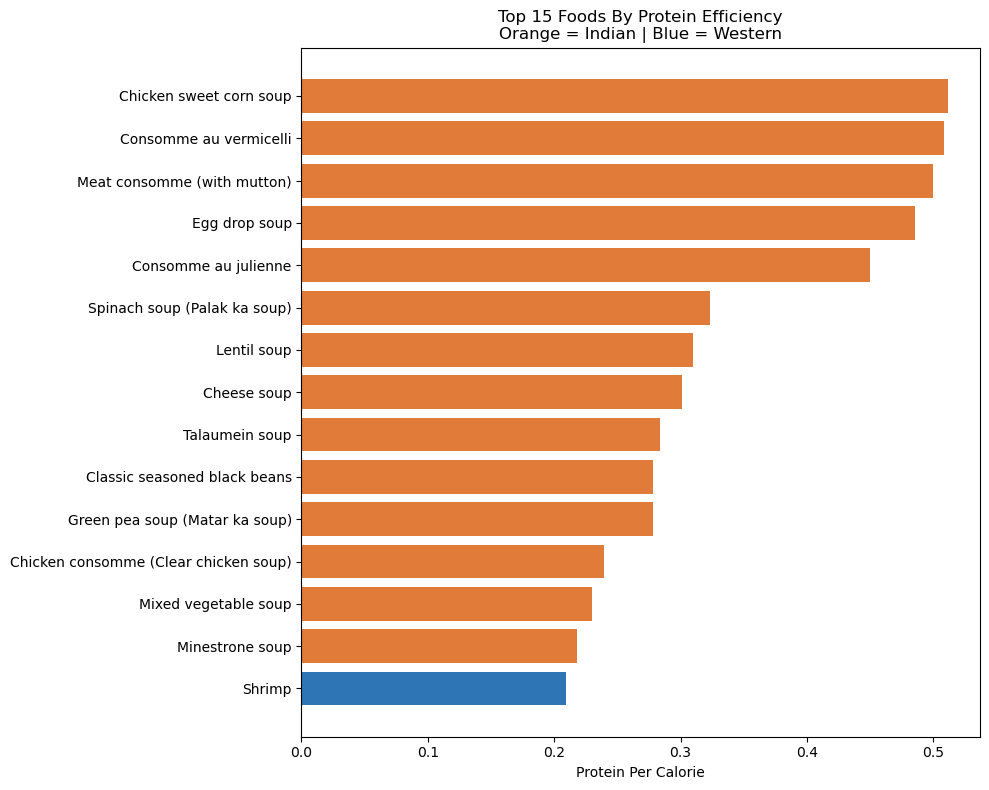

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.barh(top15["Food"], top15["protein_per_calorie"], color=colors)
plt.xlabel("Protein Per Calorie")
plt.title("Top 15 Foods By Protein Efficiency\nOrange = Indian | Blue = Western")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("protein_efficiency_top15.png")
plt.show()

In [63]:
import pandas as pd

# Western dataset
df_western = pd.read_csv(r"C:\Users\DEVIL\PythonPrograms\nutrients_csvfile.csv")
df_western["Calories"] = pd.to_numeric(df_western["Calories"], errors="coerce")
df_western["Protein"] = pd.to_numeric(df_western["Protein"], errors="coerce")
df_western["Fat"] = pd.to_numeric(df_western["Fat"], errors="coerce")
df_western["Fiber"] = pd.to_numeric(df_western["Fiber"], errors="coerce")
df_western["Carbs"] = pd.to_numeric(df_western["Carbs"], errors="coerce")
df_western["Fat"] = df_western["Fat"].fillna(0)
df_western["Sat.Fat"] = df_western["Sat.Fat"].fillna(0)
df_western.dropna(inplace=True)
df_western = df_western.drop([30, 31, 82])

# Indian dataset
df_indian = pd.read_csv(r"C:\Users\DEVIL\PythonPrograms\Indian_Food_Nutrition_Processed.csv")
df_indian.rename(columns={"Dish Name": "Food", "Calories (kcal)": "Calories", "Protein (g)": "Protein", "Fats (g)": "Fat", "Fibre (g)": "Fiber", "Carbohydrates (g)": "Carbs"}, inplace=True)
df_indian["Category"] = "Indian Dishes"

# Combine
df_combined = pd.concat([df_western, df_indian], ignore_index=True)
df_combined["protein_per_calorie"] = df_combined["Protein"] / df_combined["Calories"]

# Save
df_combined.to_csv("nutrition_combined.csv", index=False)
print(len(df_combined))

1274


In [64]:
import sqlite3
print("SQLite ready")

SQLite ready


In [65]:
conn = sqlite3.connect("nutrition.db")
df_combined.to_sql("Foods", conn, if_exists="replace", index=False)
print("Database Created Successfully")

Database Created Successfully


In [66]:
query = "SELECT Food, Calories, Protein FROM foods LIMIT 10"
result = pd.read_sql_query(query, conn)
print(result)

                    Food  Calories  Protein
0             Cows' milk     660.0     32.0
1              Milk skim     360.0     36.0
2             Buttermilk     127.0      9.0
3  Evaporated, undiluted     345.0     16.0
4          Powdered milk     515.0     27.0
5          skim, instant     290.0     30.0
6      skim, non-instant     290.0     30.0
7            Goats' milk     165.0      8.0
8    (1/2 cup ice cream)     690.0     24.0
9                  Cocoa     235.0      8.0


In [67]:
query = "SELECT Food, Protein, protein_per_calorie FROM foods ORDER BY protein_per_calorie DESC LIMIT 10"
result = pd.read_sql_query(query, conn)
print(result)

                           Food  Protein  protein_per_calorie
0       Chicken sweet corn soup    14.48             0.511299
1        Consomme au vermicelli    15.23             0.508684
2   Meat consomme (with mutton)    14.86             0.499328
3                 Egg drop soup    12.93             0.485360
4          Consomme au julienne    12.49             0.449928
5  Spinach soup (Palak ka soup)    10.54             0.323412
6                   Lentil soup     9.65             0.309593
7                   Cheese soup    12.39             0.301240
8                Talaumein soup    10.12             0.284030
9  Classic seasoned black beans     8.01             0.278318


In [68]:
query = "SELECT Food, Calories, Protein FROM Foods WHERE Calories < 200 ORDER BY Protein DESC LIMIT 10"
result = pd.read_sql_query(query, conn)
print(result)

          Food  Calories  Protein
0    uncreamed     195.0     38.0
1          Cod     170.0     28.0
2    Swordfish     180.0     27.0
3      Halibut     182.0     26.0
4         Tuna     170.0     25.0
5  Ground lean     185.0     24.0
6      chicken     185.0     23.0
7         Veal     185.0     23.0
8       Shrimp     110.0     23.0
9  Corned beef     185.0     22.0
